In [1]:
import pandas as pd
import folium
from keplergl import KeplerGl
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf

from shapely.geometry import Point, LineString, Polygon, MultiPoint
import branca.colormap as cm

In [2]:
def leq(levels):
    """Get the Leq from a list of levels
    Args:
        levels: list of levels
        
    Returns:
        leq: Leq
    """
    levels = levels[~np.isnan(levels)]
    l = np.array(levels)
    return 10*np.log10(np.mean(np.power(10,l/10)))

# preparing csv file

## gps csv file

In [31]:
# csv_gps_file = r"C:\Users\scjaa\Downloads\20240327_132708_gps.csv"
# csv_gps_file = r"C:\Users\scjaa\Downloads\20240402_095659_gps.csv"
# csv_gps_file = r"C:\Users\scjaa\AAC - CENTRO DE ACUSTICA APLICADA, S.L\I + D + i - Documentos\2024\pavimentos\log_gps\20240402_110746_gps.csv"
csv_gps_file = r"C:\Users\scjaa\Downloads\20240523_162519_gps.csv"
data_gps = pd.read_csv(csv_gps_file)
data_gps = data_gps.dropna()
data_gps = data_gps[(data_gps['lat'] != 0) & (data_gps['lon'] != 0) & (data_gps['speed'] != 0)]
# change column name system_date to Time
data_gps = data_gps.rename(columns={'system_date': 'Time'})
# change this time format 2024-04-02 11:07:47.783758 to 2024-04-02 11:07:47
data_gps['Time'] = data_gps['Time'].str.slice(0, 19)
data_gps['Time'] = pd.to_datetime(data_gps['Time'])
data_gps

,Time,lat,lon,speed
1,2024-05-23 16:25:21,43.309533,-1.882178,0.575
2,2024-05-23 16:25:22,43.309532,-1.882178,0.172
3,2024-05-23 16:25:23,43.309532,-1.882178,0.146
4,2024-05-23 16:25:24,43.309532,-1.882178,0.355
5,2024-05-23 16:25:25,43.309531,-1.882177,0.053
...,...,...,...,...
7915,2024-05-23 19:00:52,43.284854,-2.326732,0.079
7916,2024-05-23 19:00:53,43.284856,-2.326725,0.240
7917,2024-05-23 19:00:54,43.284858,-2.326712,0.237
7918,2024-05-23 19:00:55,43.284860,-2.326704,0.070


In [35]:
start_time_recording = '2024-05-23 16:38:26'  # 38 + 42 = 80 --> 1h20m + 2h = 3h20m ---> 19:20:26
end_time_recording = '2024-05-23 18:23:47'

In [36]:
data_gps = data_gps[(data_gps['Time'] >= start_time_recording) & (data_gps['Time'] <= end_time_recording)]
data_gps

,Time,lat,lon,speed
667,2024-05-23 16:38:26,43.309514,-1.882201,0.986
668,2024-05-23 16:38:27,43.309512,-1.882197,1.155
669,2024-05-23 16:38:28,43.309509,-1.882194,1.716
670,2024-05-23 16:38:29,43.309499,-1.882183,2.619
671,2024-05-23 16:38:30,43.309493,-1.882179,2.251
...,...,...,...,...
6018,2024-05-23 18:23:42,43.294401,-1.900314,2.186
6019,2024-05-23 18:23:44,43.294409,-1.900324,2.319
6020,2024-05-23 18:23:45,43.294412,-1.900329,1.855
6021,2024-05-23 18:23:46,43.294416,-1.900333,1.652


## spl csv file

In [37]:
# csv_spl_file = r"C:\Users\scjaa\Downloads\20240318_164928_spl.csv"
csv_spl_file = r"C:\Users\scjaa\Downloads\20240523_162523.csv"
data_spl = pd.read_csv(csv_spl_file)
data_spl = data_spl.dropna()
data_spl['Time'] = pd.to_datetime(data_spl['Time'])
data_spl.set_index('Time', inplace=True)
resampled_spl = data_spl.resample('1s').apply(leq)
resampled_spl

,LA,LZ
Time,,
2024-05-23 16:25:24,51.523555,74.147466
2024-05-23 16:25:25,51.333546,74.416386
2024-05-23 16:25:26,58.703804,72.952129
2024-05-23 16:25:27,69.581222,75.382166
2024-05-23 16:25:28,73.554856,79.601796
...,...,...
2024-05-23 19:02:50,67.727131,98.984193
2024-05-23 19:02:51,56.128196,80.106248
2024-05-23 19:02:52,58.697302,72.676226


In [38]:
resampled_spl = resampled_spl[(resampled_spl.index >= start_time_recording) & (resampled_spl.index <= end_time_recording)]
resampled_spl

,LA,LZ
Time,,
2024-05-23 16:38:26,60.093411,74.929612
2024-05-23 16:38:27,61.003105,75.002848
2024-05-23 16:38:28,63.031553,76.834634
2024-05-23 16:38:29,63.094840,77.539944
2024-05-23 16:38:30,63.516490,77.698869
...,...,...
2024-05-23 18:23:43,65.746354,75.815271
2024-05-23 18:23:44,62.650732,78.333617
2024-05-23 18:23:45,67.065395,78.788414


## merge gps and spl dataframes

In [39]:
data_gps.set_index('Time', inplace=True)

start_time_gps = data_gps.index.min()

# Trim the resampled_spl to start from the start_time_gps or later
resampled_spl_aligned = resampled_spl[resampled_spl.index >= start_time_gps]

# Now, remove rows with NaN in resampled_spl_aligned
resampled_spl_aligned_clean = resampled_spl_aligned.dropna()

# Merge the dataframes on their index, aligning by the 'Time'
merged_data = data_gps.merge(resampled_spl_aligned_clean, left_index=True, right_index=True, how='left')

# Reset index if you want 'Time' back as a column
merged_data.reset_index(inplace=True)

merged_data

,Time,lat,lon,speed,LA,LZ
0,2024-05-23 16:38:26,43.309514,-1.882201,0.986,60.093411,74.929612
1,2024-05-23 16:38:27,43.309512,-1.882197,1.155,61.003105,75.002848
2,2024-05-23 16:38:28,43.309509,-1.882194,1.716,63.031553,76.834634
3,2024-05-23 16:38:29,43.309499,-1.882183,2.619,63.094840,77.539944
4,2024-05-23 16:38:30,43.309493,-1.882179,2.251,63.516490,77.698869
...,...,...,...,...,...,...
5347,2024-05-23 18:23:42,43.294401,-1.900314,2.186,63.640909,74.907825
5348,2024-05-23 18:23:44,43.294409,-1.900324,2.319,62.650732,78.333617
5349,2024-05-23 18:23:45,43.294412,-1.900329,1.855,67.065395,78.788414
5350,2024-05-23 18:23:46,43.294416,-1.900333,1.652,60.082895,73.979779


In [40]:
# save the merged data to a csv file
output_csv_filename = "Errenteria_20240513_113229_133629.csv"
merged_data.to_csv (output_csv_filename, index = False, header=True)

# prepare map

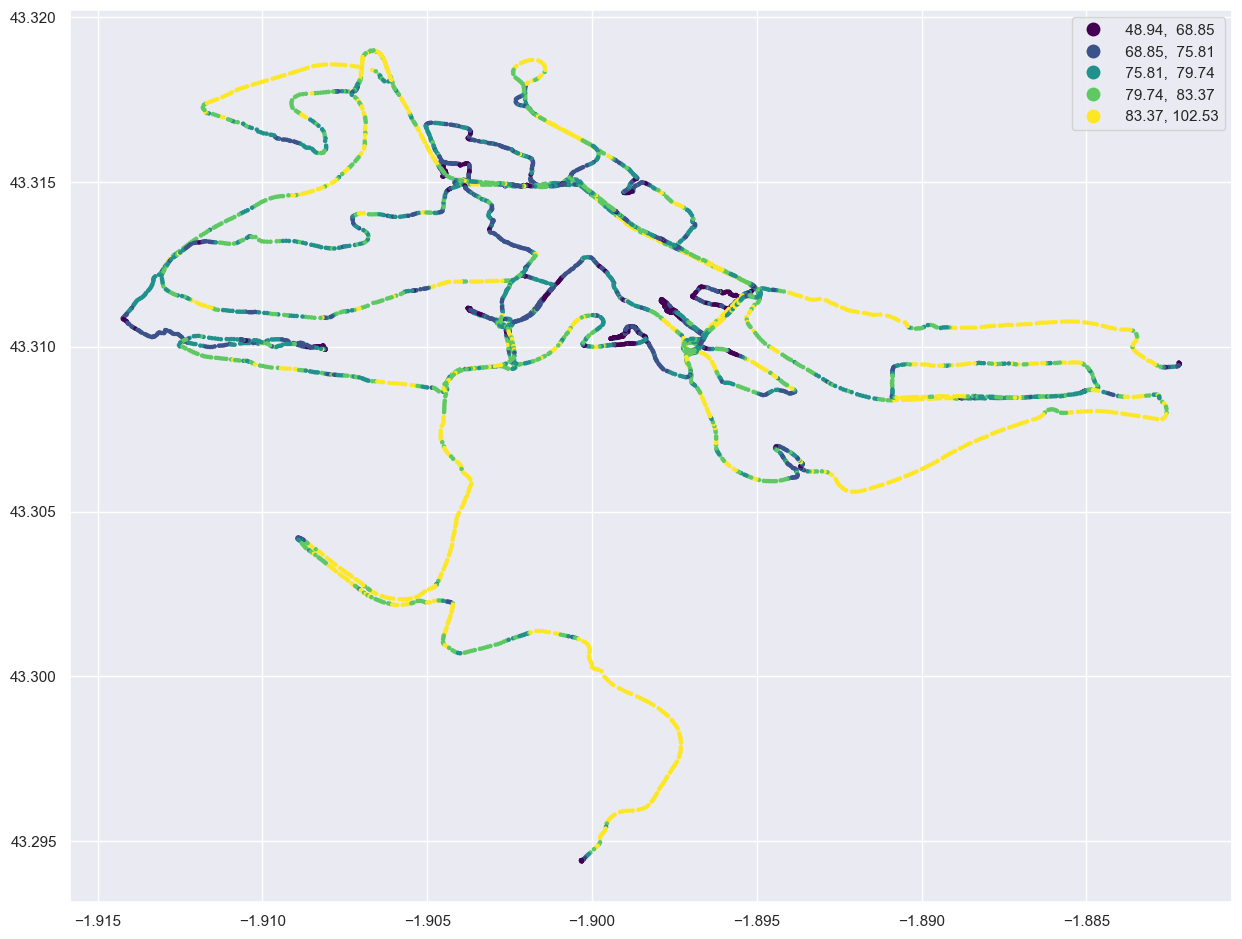

In [80]:
gdf = gpd.GeoDataFrame(merged_data, geometry=gpd.points_from_xy(merged_data.lon, merged_data.lat))
fig, ax = plt.subplots(1, 1, figsize=(15, 25))
gdf.plot(ax=ax, column='LA', legend=True, cmap='viridis', 
         marker='o', markersize=5, scheme="quantiles")

plt.show()

# save plot
output_plot_filename = "Errenteria_map_20240513_113229_133629.png"
fig.savefig(output_plot_filename)

In [78]:
# Create a Kepler.gl map
map_1 = KeplerGl(height=500)

# Add the GPS data to the map
map_1.add_data(data=merged_data, name='gps_data')

# Display the map
map_1

# save the map to a html file
map_1.save_to_html(file_name=r"C:\Users\scjaa\Downloads\kepler_map\20240318_164928_spl_gps.html")

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


ValueError: Can't clean for JSON: Interval(-0.0244, 7.599, closed='right')

# Correction part

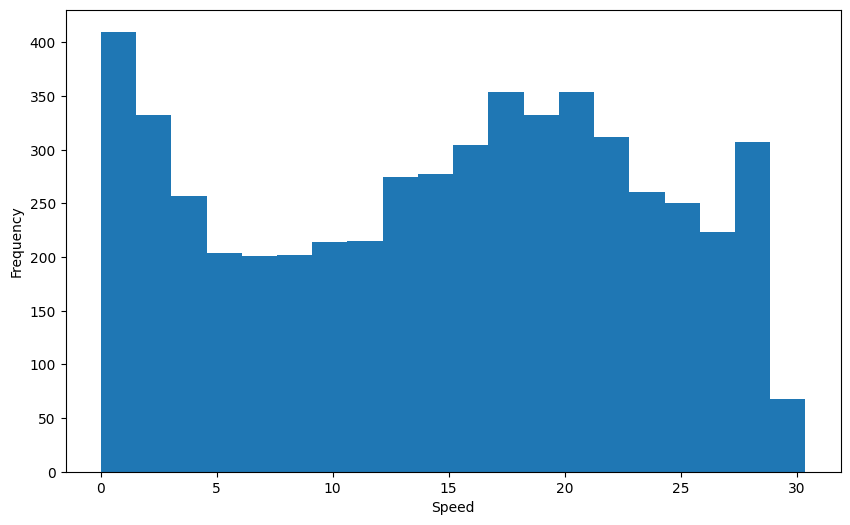

In [48]:
# histogram of the speed
plt.figure(figsize=(10, 6))
plt.hist(merged_data['speed'], bins=20)
plt.xlabel('Speed')
plt.ylabel('Frequency')
plt.show()

In [49]:
# plot the max speed and mean and min
max_speed = merged_data['speed'].max()
mean_speed = merged_data['speed'].mean()
min_speed = merged_data['speed'].min()
print('Max speed:', max_speed)
print('Mean speed:', mean_speed)
print('Min speed:', min_speed)

Max speed: 30.377
Mean speed: 14.701839872944694
Min speed: 0.006


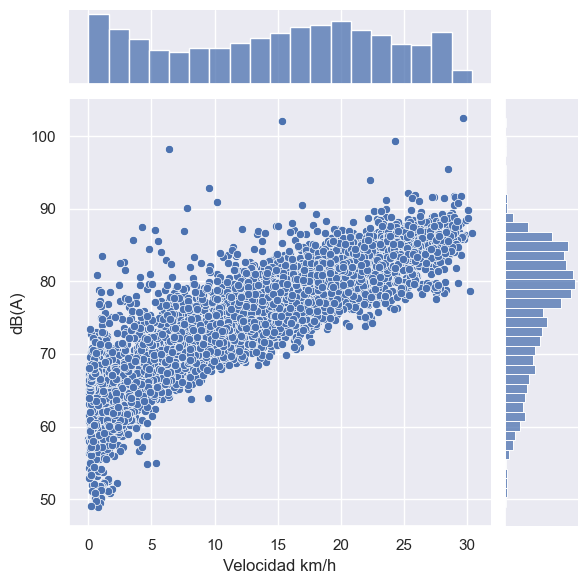

In [76]:
sns.jointplot(data=merged_data, x="speed", y="LA")
plt.xlabel("Velocidad km/h")
plt.ylabel("dB(A)")

# save plot
plt.savefig("Errenteria_corralation_speed_spl.png")

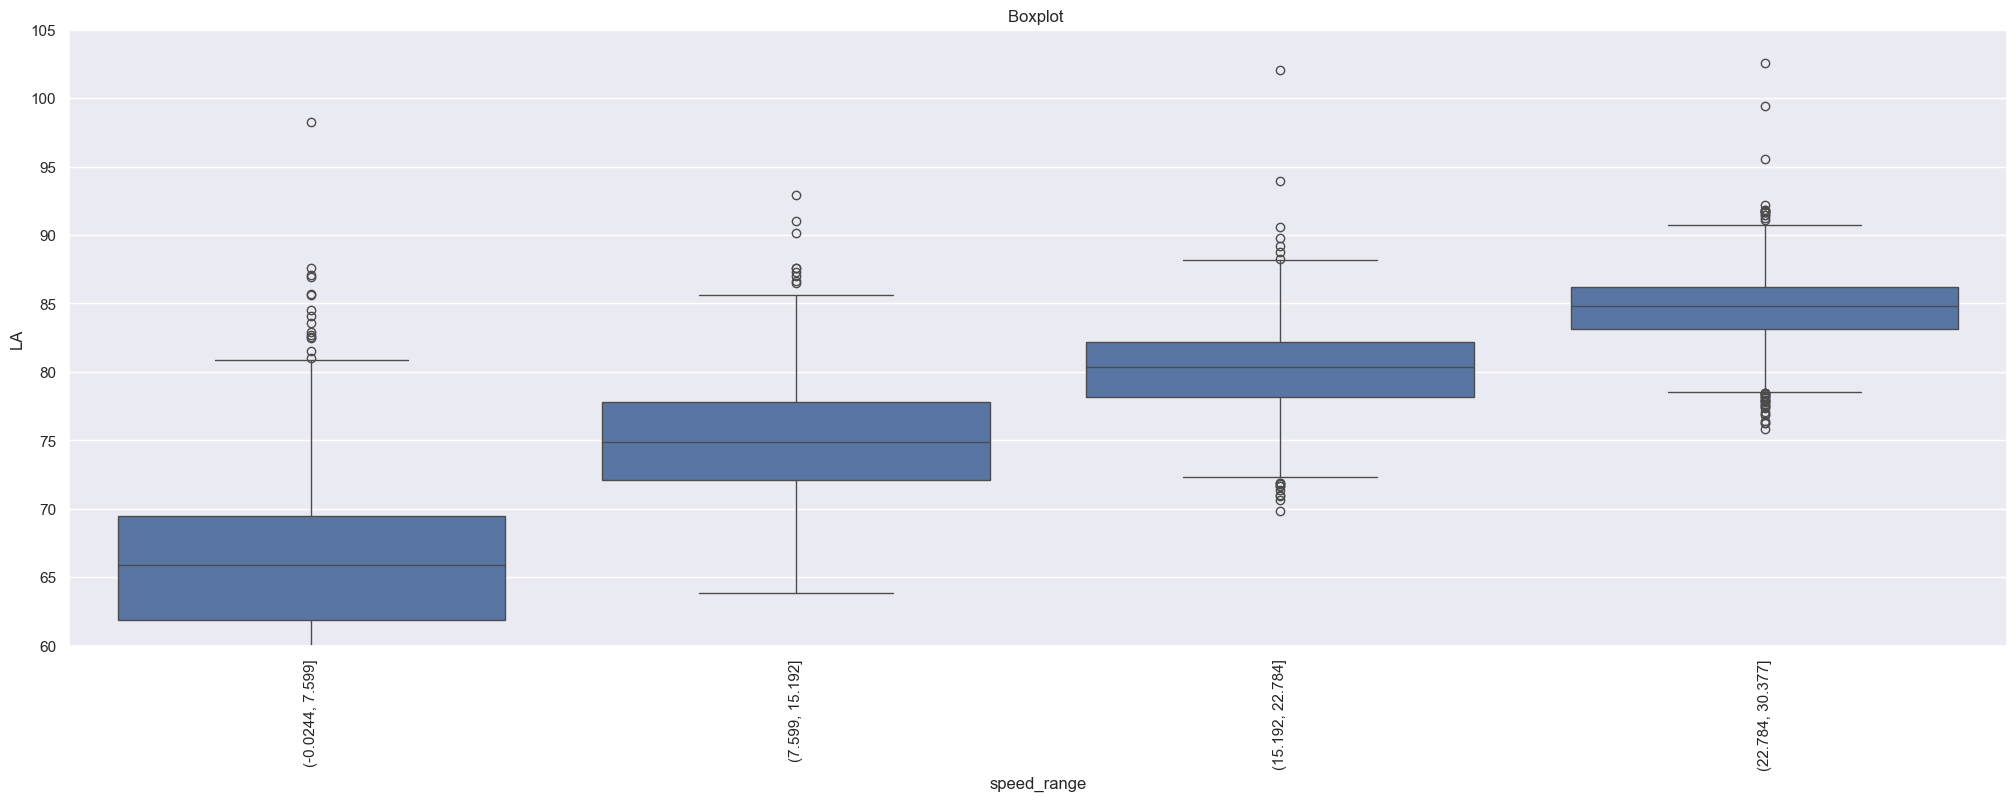

In [75]:
merged_data["speed_range"] = pd.cut(merged_data["speed"],bins=4)
sns.boxplot(data=merged_data,x="speed_range",y="LA")
plt.ylim([60,105])
sns.set(rc={'figure.figsize':(25,8)})
plt.xticks(rotation=90)
plt.title("Boxplot ")

# save the plot to a file
plt.savefig("Errenteria_20240513_113229_133629_speed_boxplot.png")

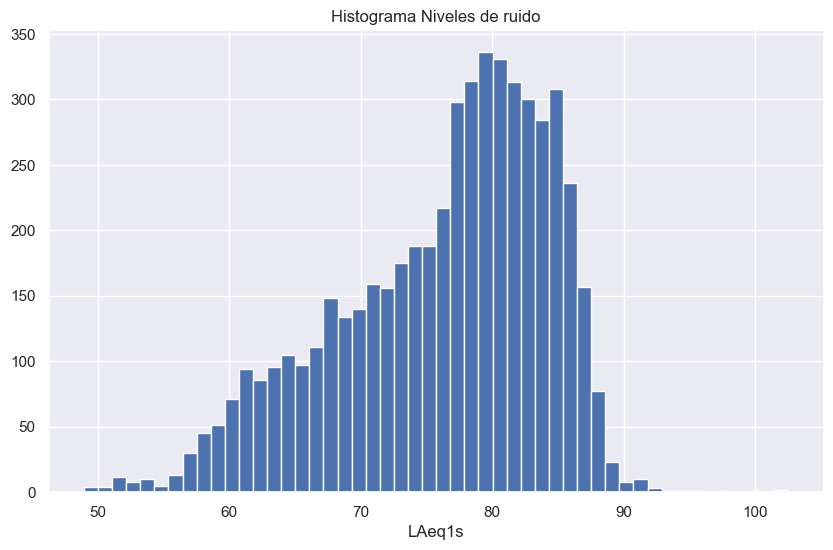

In [74]:
plt.figure(figsize=(10, 6))
merged_data["LA"].hist(bins=50)
plt.xlabel("LAeq1s")
plt.title("Histograma Niveles de ruido")

# save histogram to a file
plt.savefig("Errenteria20240318_164928_spl_histogram.png")

In [57]:
merged_data 

,Time,lat,lon,speed,LA,LZ,speed_range
0,2024-05-23 16:38:26,43.309514,-1.882201,0.986,60.093411,74.929612,"(-0.0244, 7.599]"
1,2024-05-23 16:38:27,43.309512,-1.882197,1.155,61.003105,75.002848,"(-0.0244, 7.599]"
2,2024-05-23 16:38:28,43.309509,-1.882194,1.716,63.031553,76.834634,"(-0.0244, 7.599]"
3,2024-05-23 16:38:29,43.309499,-1.882183,2.619,63.094840,77.539944,"(-0.0244, 7.599]"
4,2024-05-23 16:38:30,43.309493,-1.882179,2.251,63.516490,77.698869,"(-0.0244, 7.599]"
...,...,...,...,...,...,...,...
5347,2024-05-23 18:23:42,43.294401,-1.900314,2.186,63.640909,74.907825,"(-0.0244, 7.599]"
5348,2024-05-23 18:23:44,43.294409,-1.900324,2.319,62.650732,78.333617,"(-0.0244, 7.599]"
5349,2024-05-23 18:23:45,43.294412,-1.900329,1.855,67.065395,78.788414,"(-0.0244, 7.599]"
5350,2024-05-23 18:23:46,43.294416,-1.900333,1.652,60.082895,73.979779,"(-0.0244, 7.599]"


In [58]:
# OLS Model: An Ordinary Least Squares (OLS) regression model is fitted where LA (sound level) is predicted using the logarithm of speed.

mod = smf.ols(formula='LA ~ np.log10(speed)', data=merged_data)
res = mod.fit()

print(res.summary())
print(res.params)

                            OLS Regression Results                            
Dep. Variable:                     LA   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                 1.090e+04
Date:                Mon, 27 May 2024   Prob (F-statistic):               0.00
Time:                        10:28:04   Log-Likelihood:                -15783.
No. Observations:                5352   AIC:                         3.157e+04
Df Residuals:                    5350   BIC:                         3.158e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          62.8192      0.143    4

C:\Users\scjaa\AppData\Local\Temp\ipykernel_23960\1792389138.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fit_model = res_params[0] + res_params[1]*np.log10(speed_vec)
C:\Users\scjaa\AppData\Local\Temp\ipykernel_23960\1792389138.py:8: RuntimeWarning: divide by zero encountered in log10
  fit_model = res_params[0] + res_params[1]*np.log10(speed_vec)
C:\Users\scjaa\AppData\Local\Temp\ipykernel_23960\1792389138.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(10,50,f"$LA = {round(res_params[0],1)} + {round(res_params[1],1)}log10(V)$")


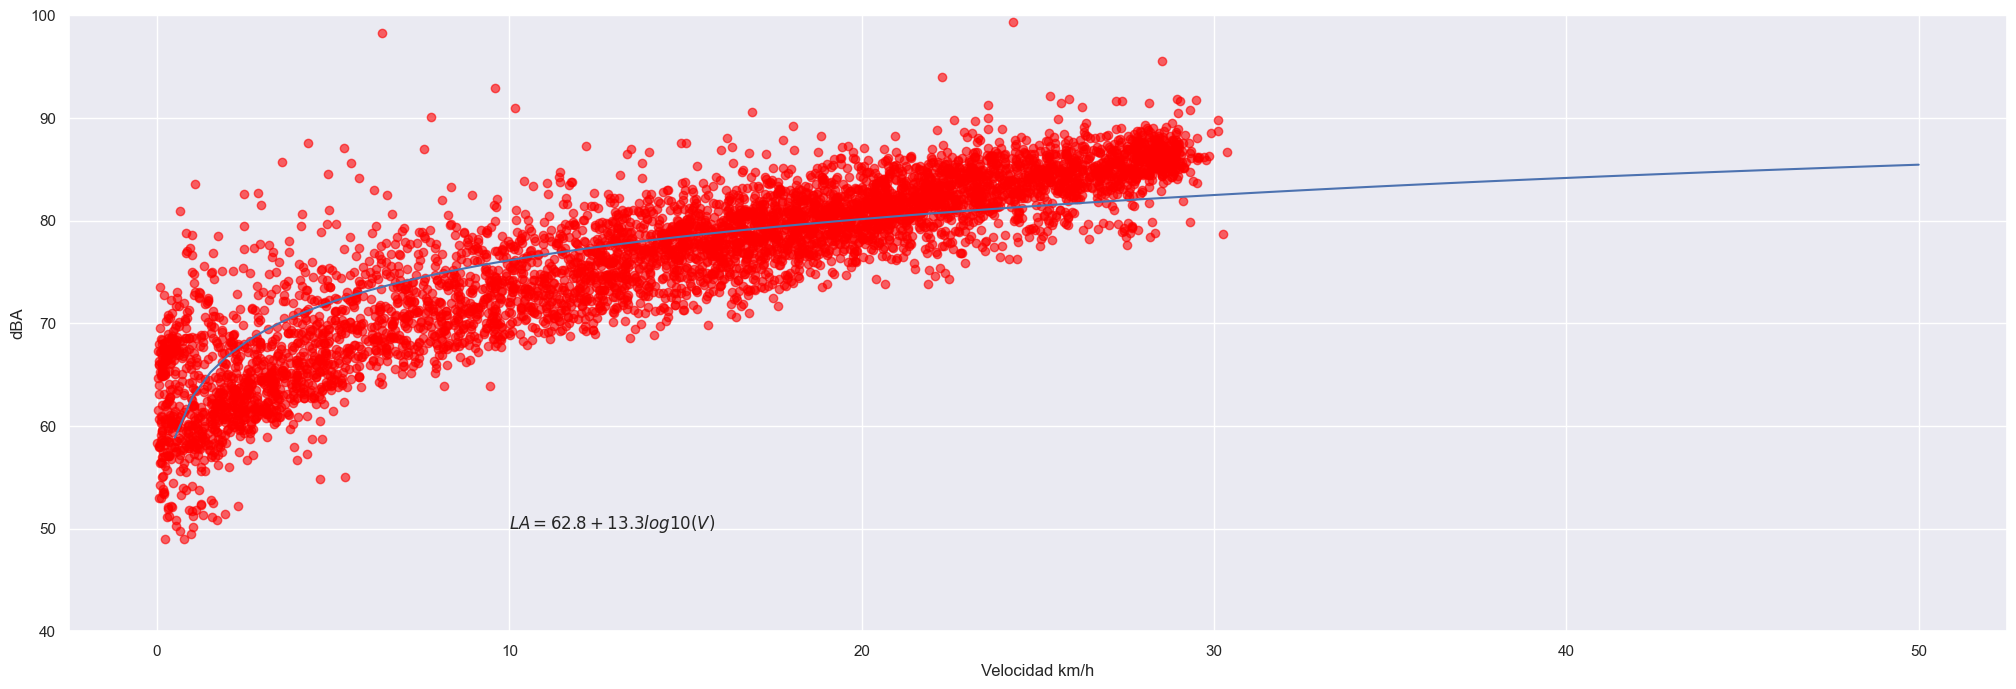

In [73]:
# Calculate Regression Line: The regression line is calculated using the model parameters.
# Scatter Plot: A scatter plot of the speed vs. LA is created.
# Plot Regression Line: The regression line is plotted over the scatter plot.
# Annotations: Text annotation for the regression equation is added to the plot.

res_params = res.params
speed_vec = np.linspace(0,50,100)
fit_model = res_params[0] + res_params[1]*np.log10(speed_vec)

plt.scatter(merged_data["speed"], merged_data["LA"],color="red",alpha=0.6)
plt.text(10,50,f"$LA = {round(res_params[0],1)} + {round(res_params[1],1)}log10(V)$")
plt.plot(speed_vec,fit_model)
plt.ylim([40,100])
plt.ylabel("dBA")
plt.xlabel("Velocidad km/h")

# save plot
plt.savefig("Errenteria_speed_vs_LA.png")

C:\Users\scjaa\AppData\Local\Temp\ipykernel_23960\1156903776.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  LA_corrected = merged_data["LA"] - res_params[1]*np.log10(merged_data["speed"]/vel_ref)


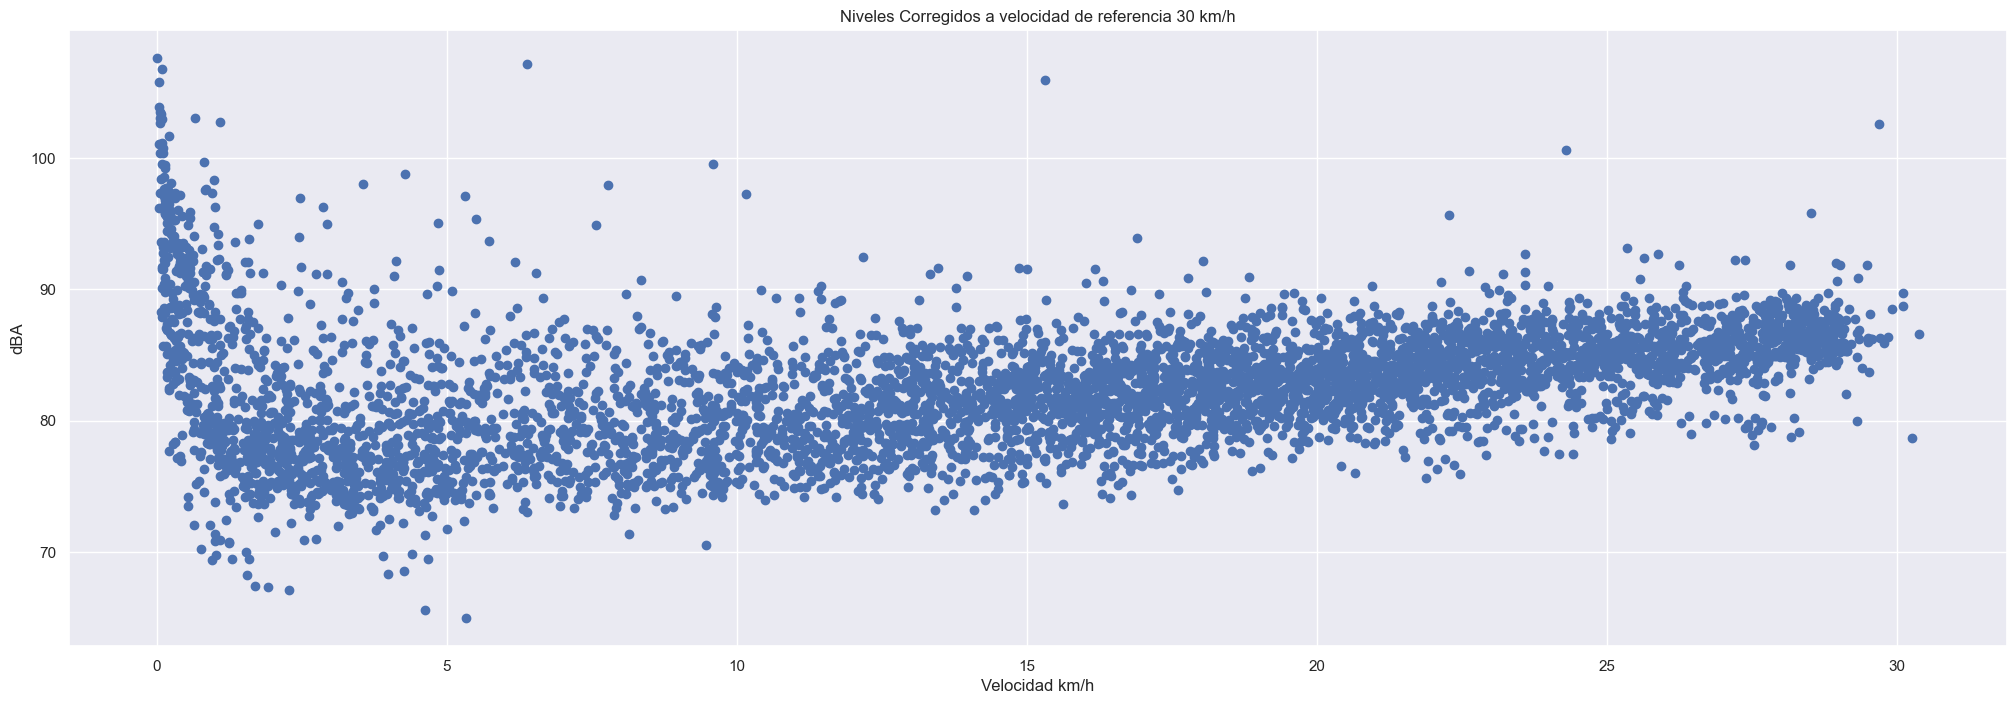

In [72]:
# Reference Speed: A reference speed of 30 km/h is defined.
# Correct LA Values: The LA values are corrected based on the reference speed.
# Plot Corrected LA Values: The corrected LA values are plotted against speed.
# Expected LA Values: Expected LA values at different speeds (25, 30, 35 km/h) are printed.

vel_ref = 30

LA_corrected = merged_data["LA"] - res_params[1]*np.log10(merged_data["speed"]/vel_ref)
plt.scatter(merged_data["speed"],LA_corrected)
merged_data["LA_corrected"] = LA_corrected
plt.title("Niveles Corregidos a velocidad de referencia 30 km/h");
plt.ylabel("dBA");
plt.xlabel("Velocidad km/h");

# save plot to a file
plt.savefig("Errenteria_Niveles_Corregidos.png")

In [61]:
# Expected Level Calculation: Calculate the expected LA level at the reference speed.
# Correction Values: Calculate the correction values by subtracting the expected level from the corrected LA.
# Histogram: Plot a histogram of the correction values.

LA_expected = res_params[0] + res_params[1]*np.log10(vel_ref)
print("25 km/h: ",res_params[0] + res_params[1]*np.log10(vel_ref - 5))
print("30 km/h: ",res_params[0] + res_params[1]*np.log10(vel_ref))
print("35 km/h: ",res_params[0] + res_params[1]*np.log10(vel_ref + 5))

25 km/h:  81.43568423996436
30 km/h:  82.4901448577098
35 km/h:  83.38167860684418


C:\Users\scjaa\AppData\Local\Temp\ipykernel_23960\1074379603.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  LA_expected = res_params[0] + res_params[1]*np.log10(vel_ref)
C:\Users\scjaa\AppData\Local\Temp\ipykernel_23960\1074379603.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("25 km/h: ",res_params[0] + res_params[1]*np.log10(vel_ref - 5))
C:\Users\scjaa\AppData\Local\Temp\ipykernel_23960\1074379603.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value

C:\Users\scjaa\AppData\Local\Temp\ipykernel_23960\2453504018.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  LA_expected = res_params[0] + res_params[1]*np.log10(vel_ref)


Nivel esperado a 30 km/h: 82.4901448577098


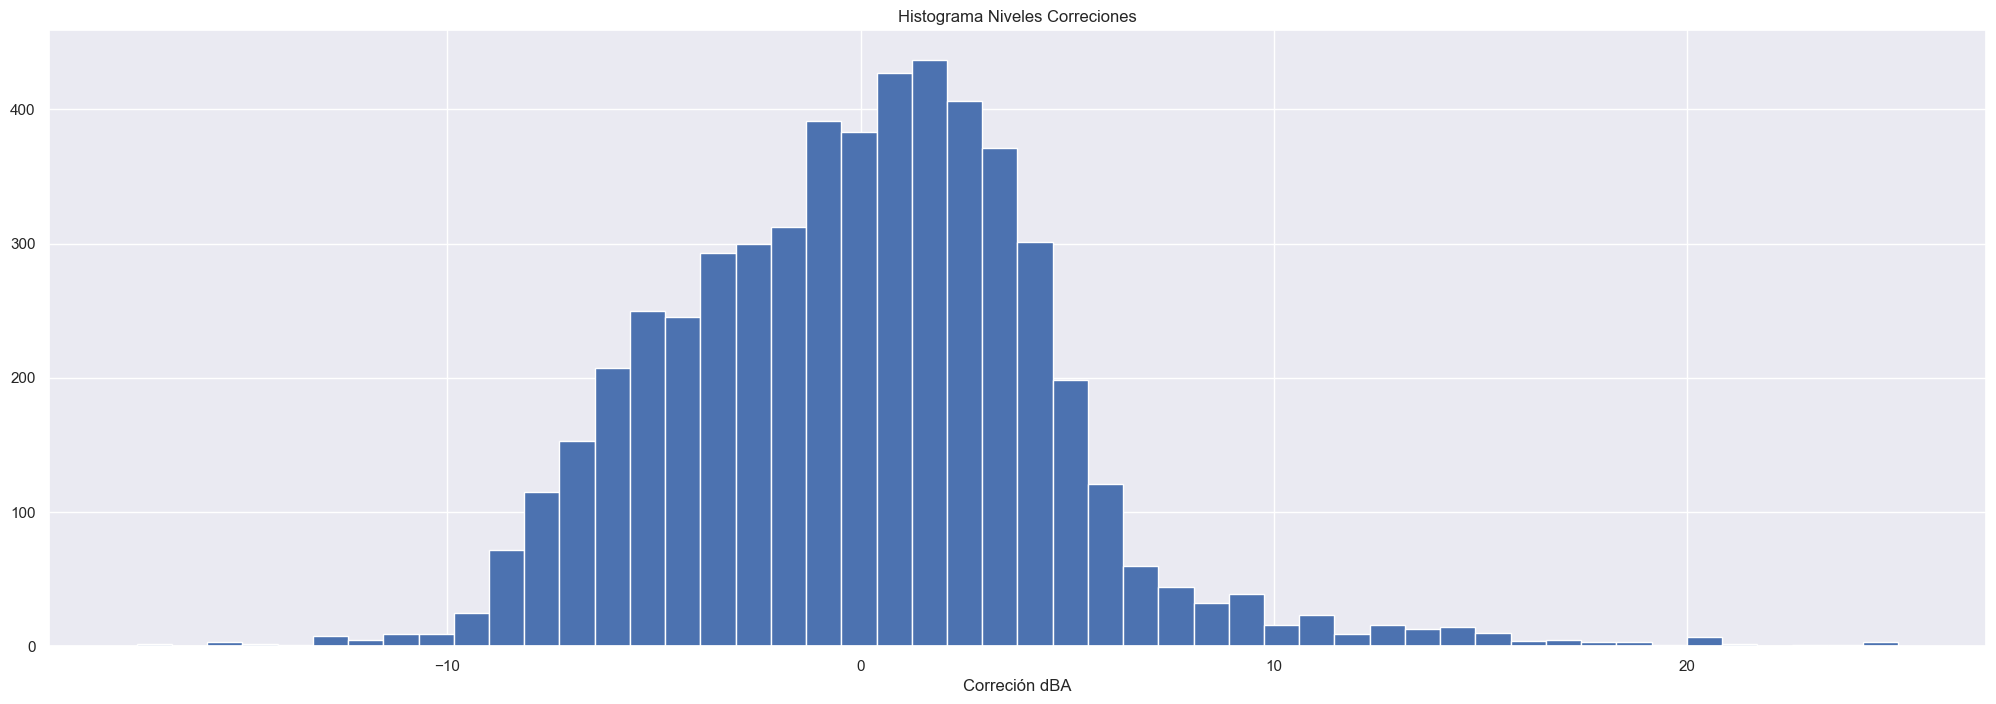

In [70]:
# Create Geometry: Convert latitude and longitude to geometrical points.
# Filter Data: Filter out invalid latitude values.
# Calculate Mean Values: Calculate mean values for every step of 10 data points.
# Create GeoDataFrame: Create a GeoDataFrame for plotting.
# Plot: Plot the mean corrected LA values.

LA_expected = res_params[0] + res_params[1]*np.log10(vel_ref)
print(f"Nivel esperado a {vel_ref} km/h: {LA_expected}")
merged_data["correction"] = merged_data["LA_corrected"] - LA_expected 

merged_data["correction"].hist(bins=50)
plt.xlabel("Correción dBA")
plt.title("Histograma Niveles Correciones")

# save plot to a file
plt.savefig("Errenteria_20240513_113229_133629.png")

In [63]:
output_csv_filename = "Errenteria_20240513_113229_133629_correction_values.csv"
merged_data.to_csv (output_csv_filename, index = False, header=True)

# GIS PostProcess

In [64]:
merged_data['geometry'] = merged_data.apply(lambda x: Point(x['lat'],x['lon']),axis=1)
merged_data = merged_data[merged_data["lat"] > 1].copy()

In [65]:
step = 10
lines = []
rounded_len = int(np.floor(len(merged_data) / step)) * step
mean_merged_data = pd.DataFrame()
dates = []


for i in range(0,rounded_len-step,step):
    merged_data_temp = merged_data.iloc[i:i+step]
    merged_data_num = merged_data_temp.select_dtypes(include=np.number)
    mean_merged_data = pd.concat([mean_merged_data,merged_data_num.mean()],axis=1)
    #lines.append(LineString([merged_data_temp['geometry'].values[0],merged_data_temp['geometry'].values[-1]]))
    lines.append(LineString(list(merged_data_temp['geometry'].values)))
    dates.append(merged_data_temp['Time'].iloc[0])
    
mean_merged_data = mean_merged_data.T
mean_merged_data['geometry'] = lines
mean_merged_data['Time'] = dates

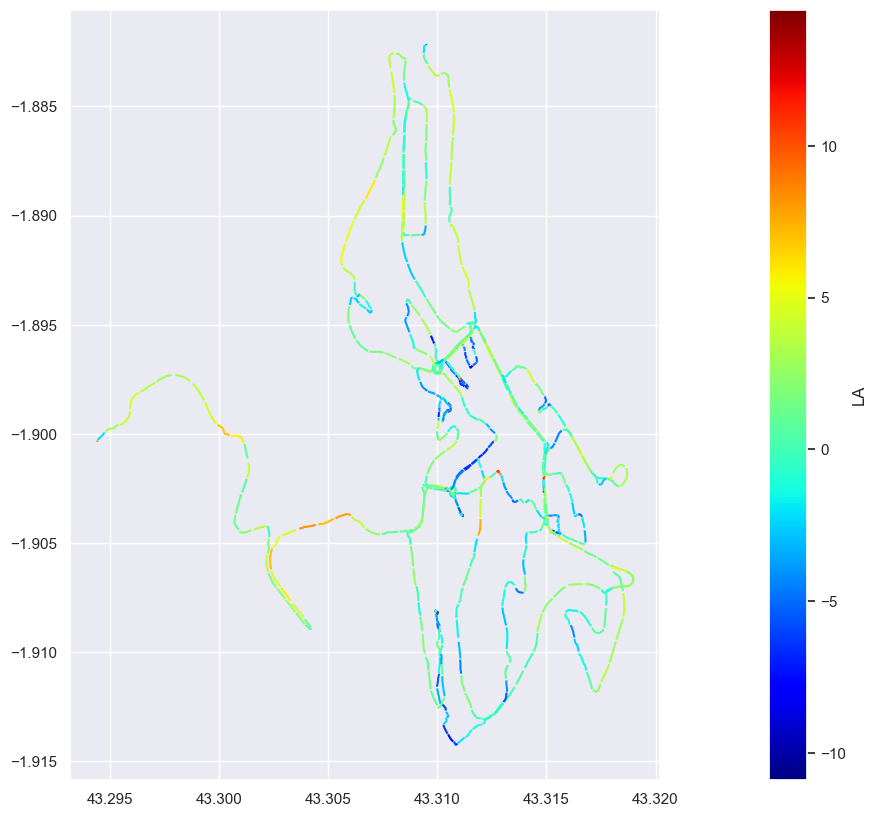

In [69]:
# to geodataframe
mean_df_geo = gpd.GeoDataFrame(mean_merged_data,crs="EPSG:4326")
df_geo = gpd.GeoDataFrame(merged_data,crs="EPSG:4326")

mean_df_geo.plot(column='correction',legend=True,legend_kwds={'label': "LA"},figsize=(28,10),cmap='jet')
# save plot
plt.savefig("Errenteria_20240513_113229_133629_correction_values.png")

In [68]:
## save speed maps
this_map = folium.Map(prefer_canvas=True)
variable = 'correction'
#v_min = merged_data[variable].min()
#v_max = merged_data[variable].max()
v_min=-6
v_max=6
index_list = list(np.linspace(v_min,v_max,5))
step = cm.LinearColormap(colors=['green','yellow', 'blue', 'purple','red'],index=index_list,vmin=v_min,vmax=v_max)

def plotDot(point):
    '''input: series that contains a numeric named latitude and a numeric named longitude
    this function creates a CircleMarker and adds it to your this_map'''
    folium.CircleMarker(location=[point.lat, point.lon],
                        fill=True,
                        color=step(point[variable]),
                        radius=2).add_to(this_map)

#use merged_data.apply(,axis=1) to "iterate" through every row in your dataframe
merged_data.apply(plotDot, axis = 1)

#Set the zoom to the maximum possible
tile = folium.TileLayer(
        tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        #tiles = '',
        attr = 'Aerial',
        name = 'Mapquest',
        overlay = False,
        control = True
    ).add_to(this_map)
this_map.fit_bounds(this_map.get_bounds())
this_map.add_child(step)

this_map
this_map.save(f'correction_map_Errenteria.html')